In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("C:\\Users\\HP\\Downloads\\netflix_titles.csv")

In [38]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,David Attenborough,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Rajiv Chilaka,David Attenborough,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Rajiv Chilaka,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### 2. Data Cleaning:

#### Check for missing values and handle them appropriately.
#### Remove duplicate entries if any.
#### Correct any inconsistencies or errors in the data

In [27]:
data.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [29]:
numercial_cols = data.select_dtypes(include="number").columns.tolist()
numercial_cols

['release_year']

In [30]:
categorical_cols = data.select_dtypes(include="object").columns.tolist()
categorical_cols

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'rating',
 'duration',
 'listed_in',
 'description']

In [31]:
for col in categorical_cols:
    # print(col)
    print(data[col].isna().sum())
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna(value=data[col].mode()[0])

print("Null values are filled successfully!")
print(data.isna().sum())

0
0
0
0
0
0
0
0
0
0
0
Null values are filled successfully!
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [32]:
data.duplicated().sum()

np.int64(0)

there is no duplicate record in the system, so we can move ahead!

## Exploratory Data Analysis:

**Compute basic descriptive statistics such as mean, median, mode, range, and standard deviation for relevant variables**

In [33]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [34]:
data['release_year'].mode()[0]

np.int64(2018)

In [35]:
print(data['release_year'].min())
print(data['release_year'].max())

1925
2021


In [36]:
data['release_year'].std()

8.819312130834057

1. Mean -> 8807.0
2. Median -> 2017.00
3. Mode -> 2018
4. Range -> [1925, 2021]
5. standard deviation -> 8.819312130834057

In [37]:
data.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2653,844,3649,119,3211,1796,362,4


##### Create visualizations to represent the distribution of content over different genres

In [39]:
data.type.unique()

array(['Movie', 'TV Show'], dtype=object)

In [40]:
data.listed_in.unique()

array(['Documentaries', 'International TV Shows, TV Dramas, TV Mysteries',
       'Crime TV Shows, International TV Shows, TV Action & Adventure',
       'Docuseries, Reality TV',
       'International TV Shows, Romantic TV Shows, TV Comedies',
       'TV Dramas, TV Horror, TV Mysteries', 'Children & Family Movies',
       'Dramas, Independent Movies, International Movies',
       'British TV Shows, Reality TV', 'Comedies, Dramas',
       'Crime TV Shows, Docuseries, International TV Shows',
       'Dramas, International Movies',
       'Children & Family Movies, Comedies',
       'British TV Shows, Crime TV Shows, Docuseries',
       'TV Comedies, TV Dramas', 'Documentaries, International Movies',
       'Crime TV Shows, Spanish-Language TV Shows, TV Dramas',
       'Thrillers',
       'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure',
       'International TV Shows, TV Action & Adventure, TV Dramas',
       'Comedies, International Movies',
       'Comedies, 

In [46]:
result = data.groupby('listed_in').size().reset_index().rename(columns={0:"counts"})
result = result.sort_values(by="counts", ascending=False)
result = result.head(7)

In [47]:
result

,listed_in,counts
326,"Dramas, International Movies",362
274,Documentaries,359
470,Stand-Up Comedy,334
200,"Comedies, Dramas, International Movies",274
319,"Dramas, Independent Movies, International Movies",252
422,Kids' TV,220
121,Children & Family Movies,215


In [48]:
import matplotlib.pyplot as plt


Text(0, 0.5, 'Frequency')

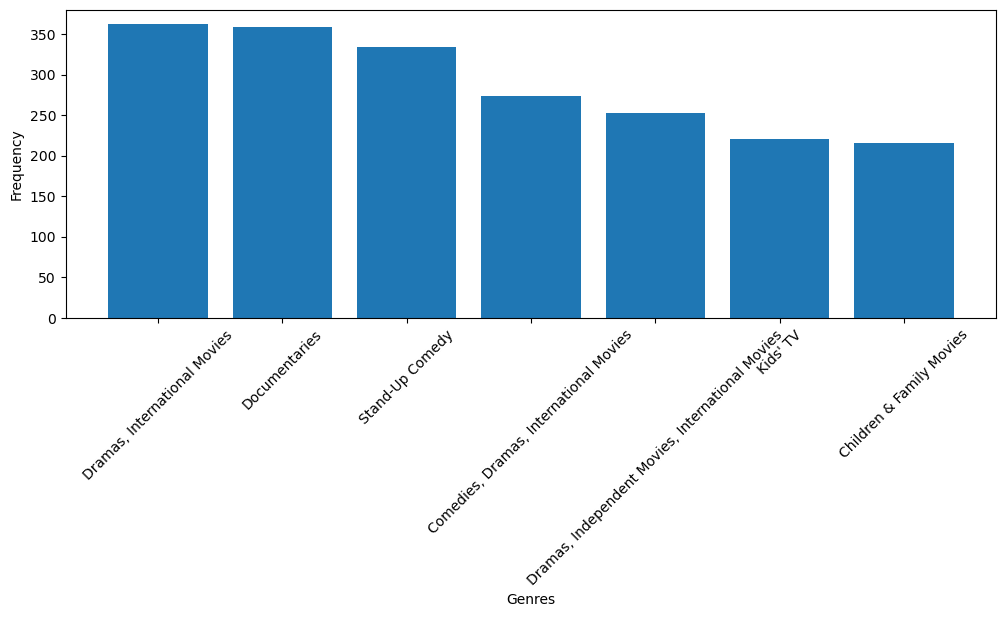

In [54]:
plt.figure(figsize=(12, 4))
plt.bar(result['listed_in'], result['counts'])
plt.xticks(rotation=45)
plt.xlabel("Genres")
plt.ylabel("Frequency")


#### insights:

1. Dramas, International Movies, and Documentaries, and Stand-up Comedy Movies are most supported by Netflix.